In [35]:
import pandas as pd 

In [36]:
df = pd.read_csv('train_ds.csv')
df.head()  # Gets us the top 5 data rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [38]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [39]:
df.fillna({'Age': df.Age.median()}, inplace = True)

In [40]:
df.fillna({'Fare': df.Fare.median()}, inplace = True)

In [41]:
df.drop('Cabin', axis = 1, inplace = True)

In [42]:
df['Survived'].value_counts()  # Gets us the number of survived and dead passengers

Survived
0    549
1    342
Name: count, dtype: int64

In [43]:
survival_rate = df['Survived'].mean()*100  # Gets us the survival rate
survival_rate

np.float64(38.38383838383838)

In [44]:
print(f"Survival Rate: {survival_rate:2f}%")

Survival Rate: 38.383838%


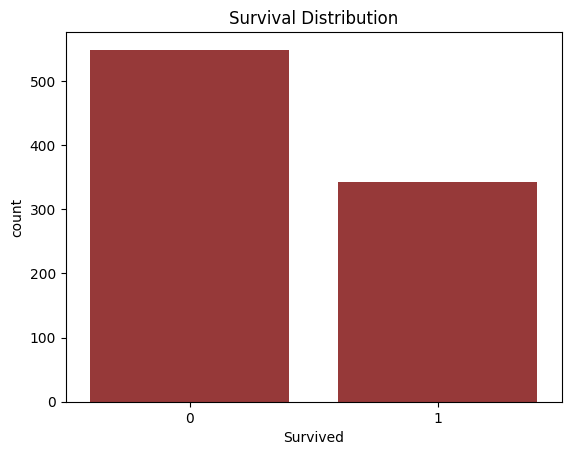

In [45]:
# This gets us the Survival Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x = 'Survived', data = df, color = 'brown')

plt.title("Survival Distribution")
plt.show()

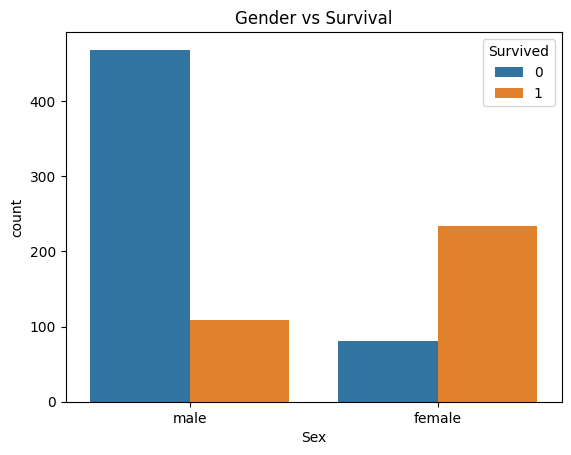

In [ ]:
sns.countplot(x = 'Sex', hue = 'Survived', data = df)

plt.title("Gender vs Survival")
plt.show()

# Females survived at a much higher rate than males

In [69]:
survival_gender = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100  # Here normalize is used to convert values into percentage

print(survival_gender)

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


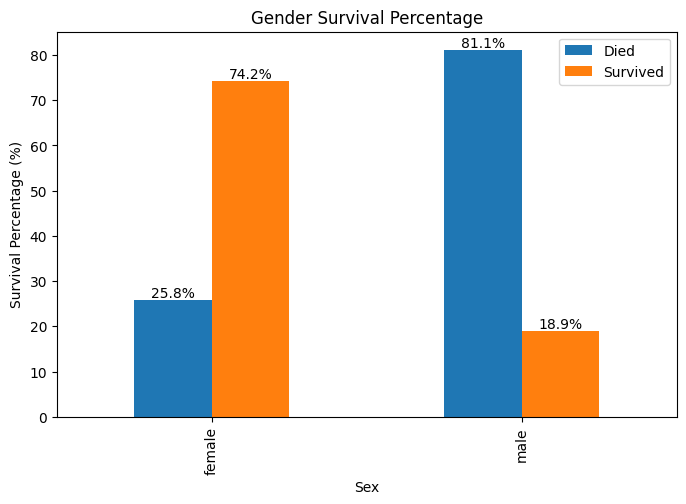

In [71]:
ax = survival_gender.plot(kind='bar', figsize=(8,5))

plt.title('Gender Survival Percentage')
plt.ylabel('Survival Percentage (%)')
plt.legend(['Died', 'Survived'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

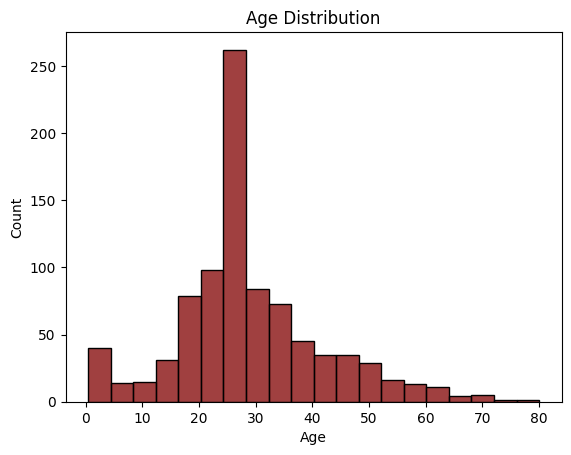

In [56]:
sns.histplot(df['Age'], bins = 20, color = 'maroon')

plt.title("Age Distribution")
plt.show()

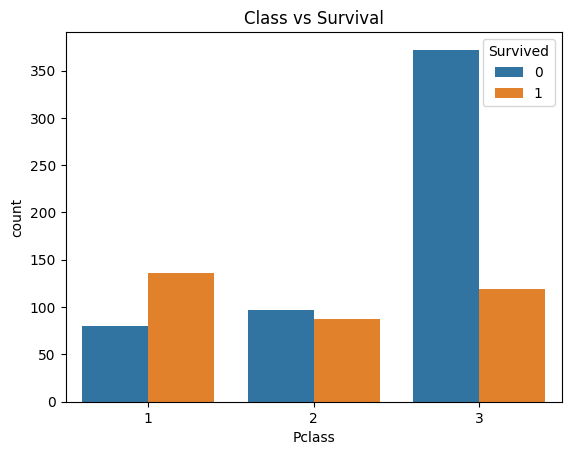

In [ ]:
sns.countplot(x = 'Pclass', hue = 'Survived', data=df)

plt.title("Class vs Survival")
plt.show()

# First class Passengers had the Highest Survival

In [ ]:
class_survival = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100 

print(class_survival)

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


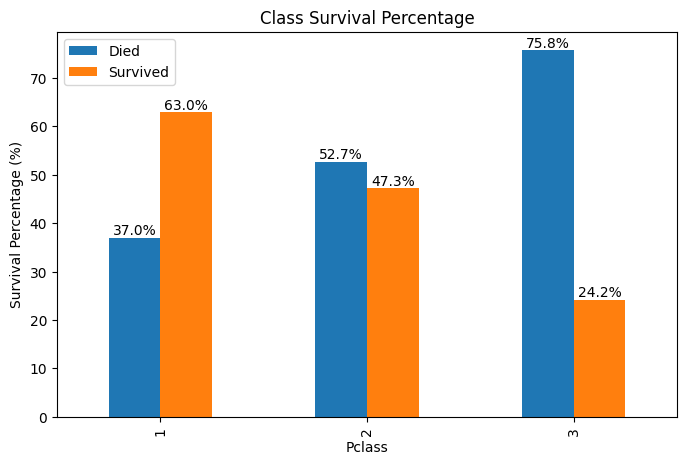

In [74]:
ax = class_survival.plot(kind='bar', figsize=(8,5))

plt.title('Class Survival Percentage')
plt.ylabel('Survival Percentage (%)')
plt.legend(['Died', 'Survived'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

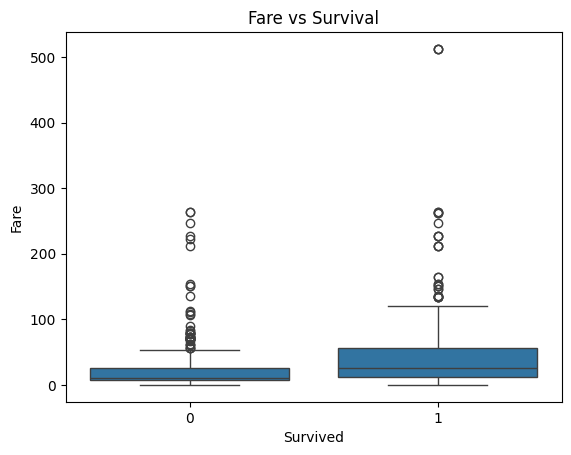

In [75]:
sns.boxplot(x = 'Survived', y = 'Fare', data = df)

plt.title("Fare vs Survival")
plt.show()

In [88]:
df['Status'] = df['Survived'].map({
    0: 'Died',
    1: 'Survived'
})

In [89]:
# Interactive Survival Chart Gender Wise

import plotly.express as px

fig = px.histogram(df, x = 'Sex', color = 'Status', title = 'Gender Wise Survival')
fig.show()

In [90]:
fig = px.histogram(df, x='Pclass', color='Status', title='Class Wise Survival')

fig.show()

## Key Insights

• Overall survival rate was approximately 38%.

• Female passengers had significantly higher survival rates.

• First-class passengers survived more frequently.

• Higher ticket fare generally correlated with survival.

• Most passengers were between 20-40 years old.